# Bank Marketing — Notebook final DS52

**Compétition Kaggle** : *Binary Classification with a Bank Dataset* (Playground Series).
**Objectif** : prédire si un client souscrit un dépôt à terme (`y ∈ {0,1}`) à l'issue d'une campagne marketing.

## Plan

1. Chargement & EDA rapide
2. Diagnostic & stratégie pour les *missing values* déguisés
3. Sélection des features (leakage `duration`, identifiants, quasi-constantes)
4. Régression linéaire (MLE) — illustration cours sur `balance`
5. Pipeline de preprocessing **anti-leakage** (`ColumnTransformer`)
6. Benchmark de 6 modèles : LogReg, GNB, LDA, QDA, Random Forest, XGBoost
7. Comparaison globale (ROC-AUC, PR-AUC, F1, Brier, calibration)
8. Calibration & choix du seuil de décision
9. Importance des features
10. Génération du fichier de soumission Kaggle
11. Conclusions

> Ce notebook utilise **`train.csv`** (avec la vraie cible `y`) pour l'entraînement et
> l'évaluation, et **`test.csv`** uniquement pour la soumission.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    f1_score, brier_score_loss, classification_report, confusion_matrix,
    mean_squared_error, r2_score,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
RNG = 42
np.random.seed(RNG)

img_dir = Path("report_images")
img_dir.mkdir(exist_ok=True)

## 1. Chargement des données

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("train :", train.shape)
print("test  :", test.shape)
print("\nColonnes train :", list(train.columns))
print("Colonnes test  :", list(test.columns))
print("\nDistribution de la cible y :")
print(train["y"].value_counts())
print(f"Taux de positifs : {train['y'].mean():.2%}")
train.head()

train : (750000, 18)
test  : (250000, 17)

Colonnes train : ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Colonnes test  : ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Distribution de la cible y :
y
0    659512
1     90488
Name: count, dtype: int64
Taux de positifs : 12.07%


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


## 2. Exploration rapide (EDA)

In [3]:
print("=== Types ===")
print(train.dtypes)
print("\n=== NaN classiques ===")
print("train :", train.isna().sum().sum(), "  test :", test.isna().sum().sum())
print("\n=== Stats numériques ===")
train.describe().T

=== Types ===
id           int64
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y            int64
dtype: object

=== NaN classiques ===
train : 0   test : 0

=== Stats numériques ===


,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
age,750000.0,40.926395,10.098829,18.0,33.00,39.0,48.00,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.00,634.0,1390.00,99717.0
day,750000.0,16.117209,8.250832,1.0,9.00,17.0,21.00,31.0
duration,750000.0,256.229144,272.555662,1.0,91.00,133.0,361.00,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.00,2.0,3.00,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.00,-1.0,-1.00,871.0
previous,750000.0,0.298545,1.335926,0.0,0.00,0.0,0.00,200.0
y,750000.0,0.120651,0.325721,0.0,0.00,0.0,0.00,1.0


### 2.1 Variables catégorielles

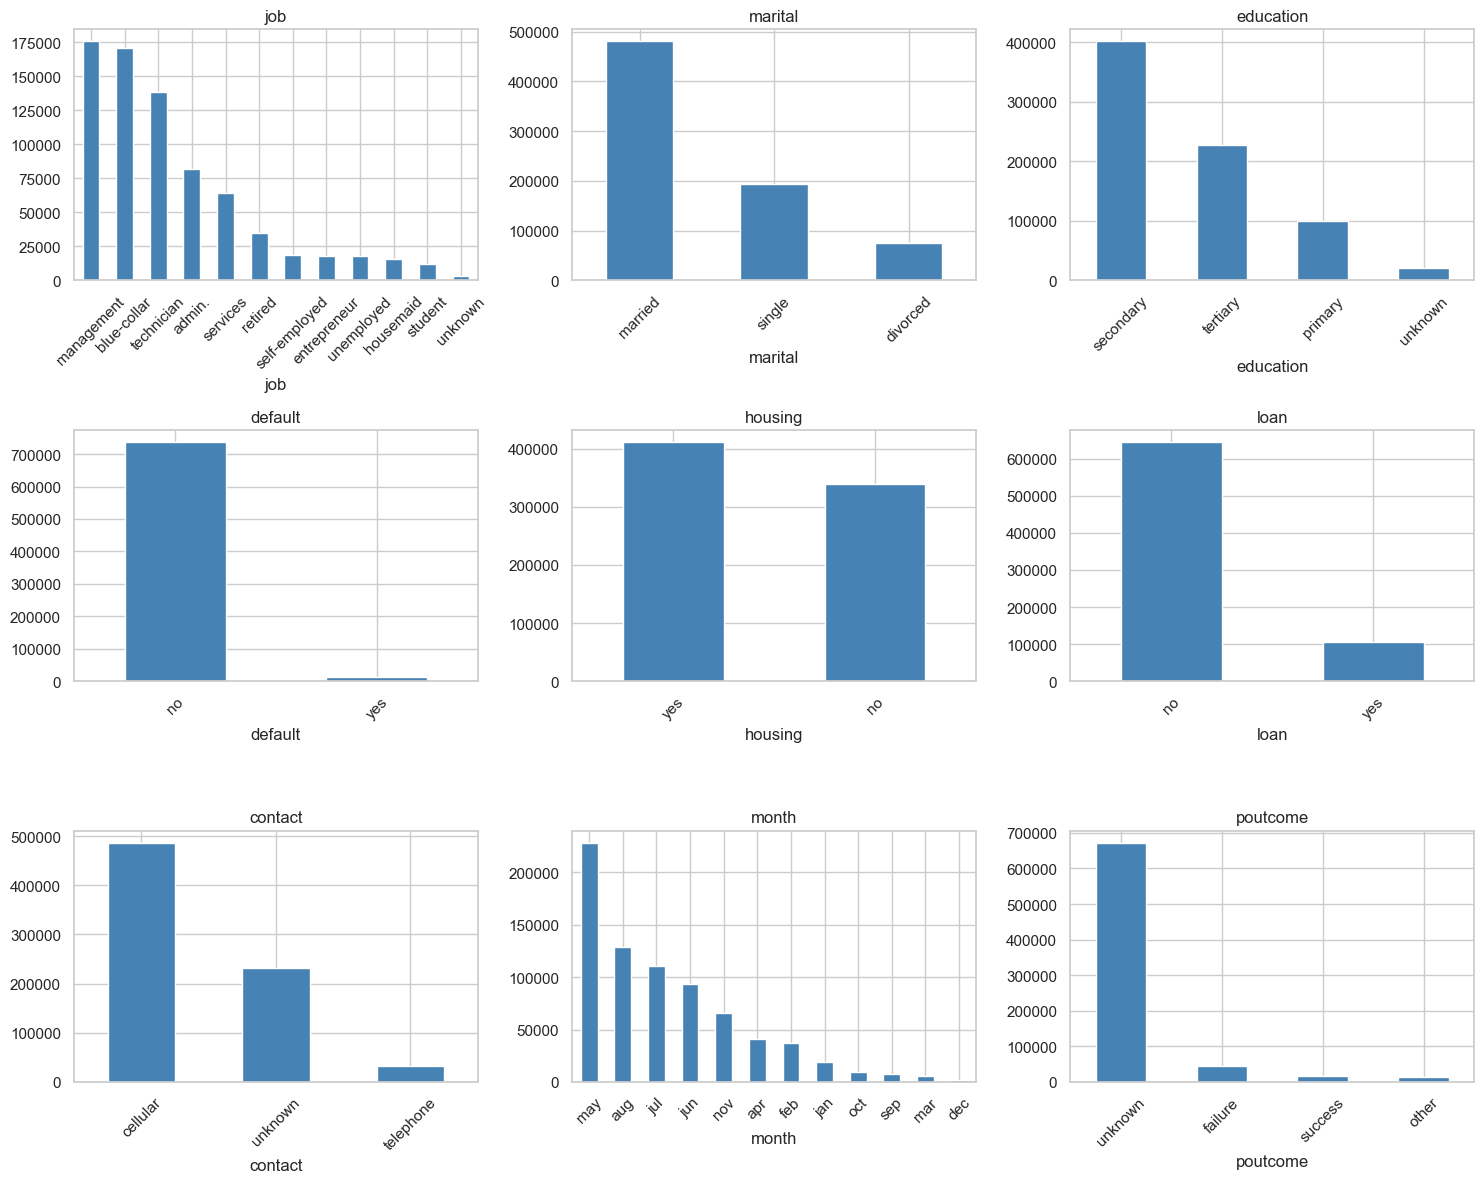

In [4]:
cat_cols = ["job","marital","education","default","housing","loan",
            "contact","month","poutcome"]
num_cols = ["age","balance","day","duration","campaign","pdays","previous"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, c in zip(axes.flat, cat_cols):
    train[c].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(c); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### 2.2 Variables numériques

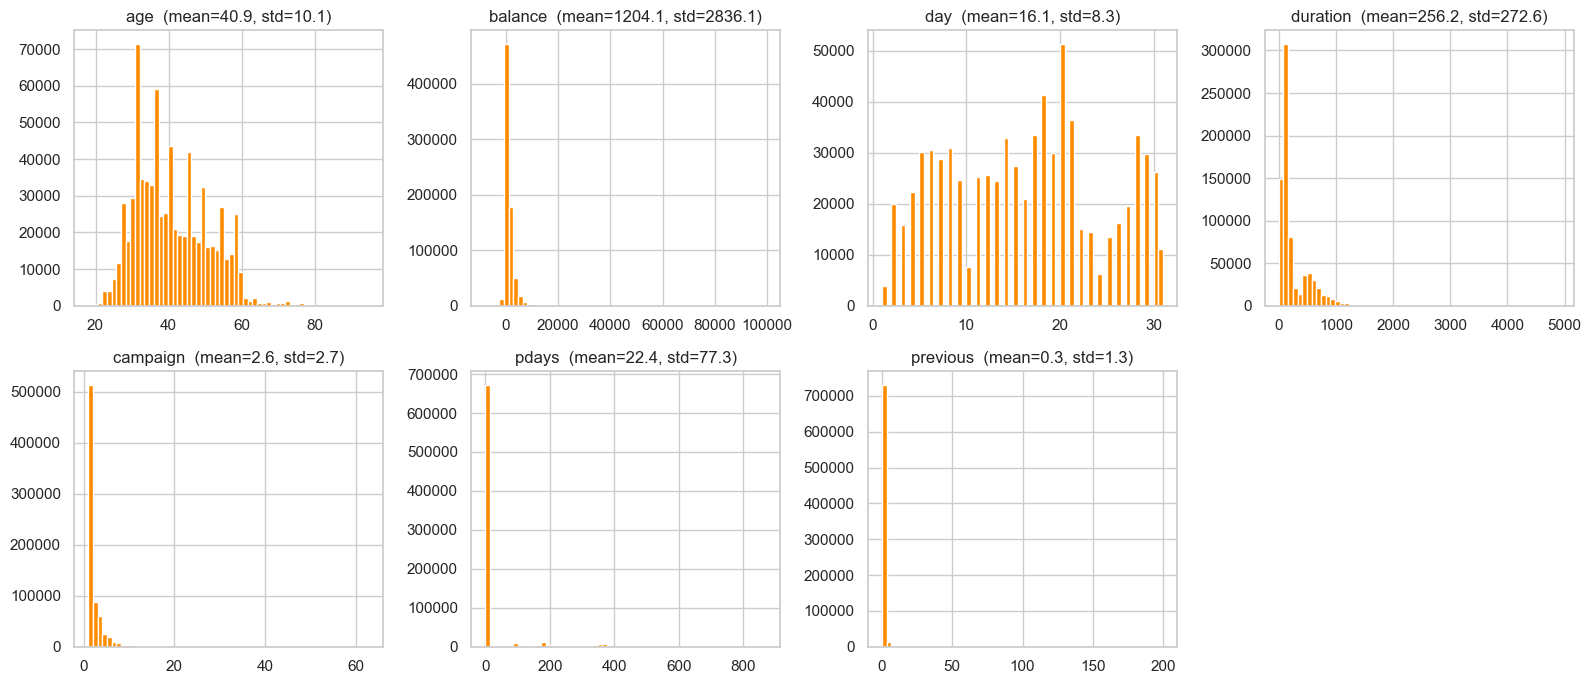

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols):
    ax.hist(train[c], bins=60, color="darkorange", edgecolor="white")
    ax.set_title(f"{c}  (mean={train[c].mean():.1f}, std={train[c].std():.1f})")
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

**Observations clés**

- `balance` très étalé (queues lourdes, max ~100k+) → log-transform utile pour modèles linéaires.
- `pdays = -1` ≈ 75% des cas ("jamais recontacté") — sentinelle, pas une vraie valeur numérique.
- `duration` : distribution exponentielle, **fortement corrélée à la cible** (cf. §3 — risque de leakage).
- `previous` très asymétrique, beaucoup de zéros.

### 2.3 Cible vs features clés

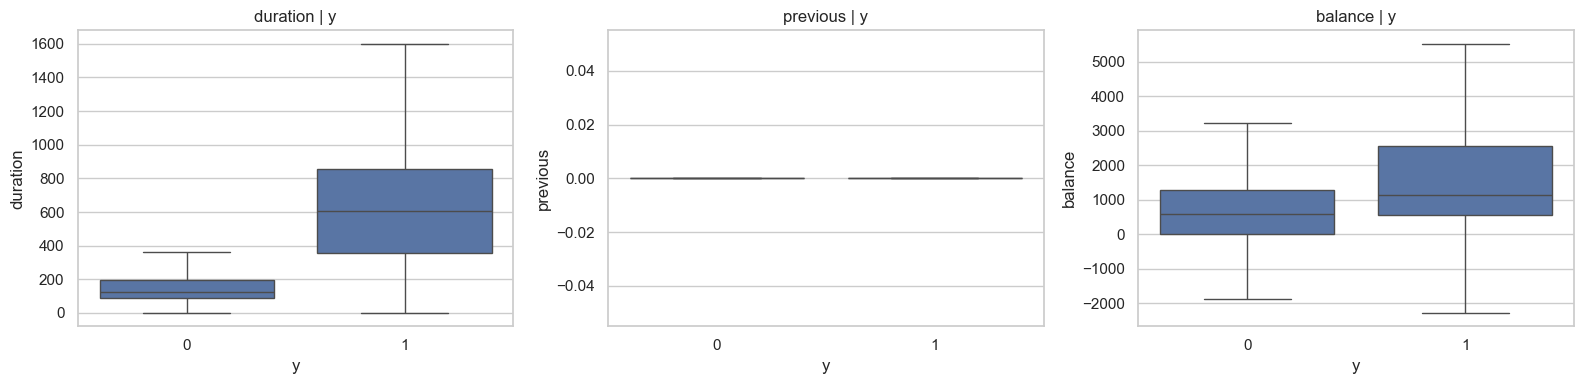

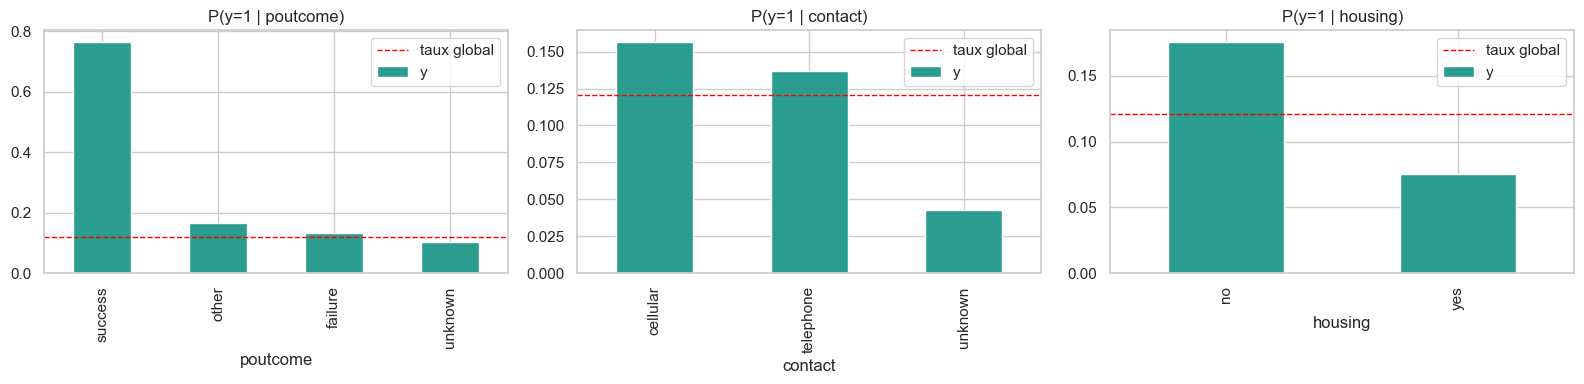

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["duration", "previous", "balance"]):
    sns.boxplot(data=train, x="y", y=c, ax=ax, showfliers=False)
    ax.set_title(f"{c} | y")
plt.tight_layout(); plt.show()

# Taux de y=1 par catégorie pour quelques variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["poutcome", "contact", "housing"]):
    rate = train.groupby(c)["y"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#2a9d8f")
    ax.axhline(train["y"].mean(), color="red", lw=1, ls="--", label="taux global")
    ax.set_title(f"P(y=1 | {c})"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Diagnostic des *missing values*

`isna().sum() == 0` mais plusieurs variables encodent des manquants en **valeurs sentinelles** :

| Variable | Code | Sémantique |
|---|---|---|
| `job`, `education`, `contact` | `"unknown"` | non renseigné |
| `poutcome` | `"unknown"` | pas de campagne précédente |
| `pdays` | `-1` | client jamais recontacté |

In [7]:
rows = []
for c in cat_cols:
    n_tr = (train[c] == "unknown").sum()
    n_te = (test[c]  == "unknown").sum()
    rows.append((c, int(n_tr), 100*n_tr/len(train), int(n_te), 100*n_te/len(test)))
rows.append((
    "pdays (=-1)",
    int((train["pdays"] == -1).sum()), 100*(train["pdays"] == -1).mean(),
    int((test["pdays"]  == -1).sum()), 100*(test["pdays"]  == -1).mean(),
))
miss = pd.DataFrame(rows, columns=["feature","n_train","%_train","n_test","%_test"])
miss.round(2)

,feature,n_train,%_train,n_test,%_test
0,job,2917,0.39,1022,0.41
1,marital,0,0.00,0,0.00
2,education,21299,2.84,7250,2.90
3,default,0,0.00,0,0.00
4,housing,0,0.00,0,0.00
5,loan,0,0.00,0,0.00
6,contact,231627,30.88,76896,30.76
7,month,0,0.00,0,0.00
8,poutcome,672450,89.66,224115,89.65
9,pdays (=-1),672434,89.66,224112,89.64


### 3.1 Stratégie retenue

**Principe** : ne pas imputer aveuglément — `"unknown"` et `pdays = -1` sont **informatifs**.

1. Catégorielles → garder `"unknown"` comme **modalité à part entière** dans le one-hot encoding.
2. `pdays` → créer un **flag binaire** `was_contacted = (pdays != -1)`, puis **remettre `pdays = 0`**
   pour les non-contactés (évite que `-1` soit interprété comme une distance numérique).
3. **Anti-leakage train/test** : le `OneHotEncoder` est *fitté* uniquement sur le pli d'entraînement
   via un `ColumnTransformer` enveloppé dans un `Pipeline` (cf. §5). On utilise
   `handle_unknown="ignore"` pour absorber d'éventuelles modalités présentes dans `test.csv`
   mais absentes du train.

## 4. Sélection des features

**Features à retirer** :

- **`id`** : identifiant pur, aucun signal prédictif.
- **`duration`** : ⚠️ *leakage temporel* documenté par l'UCI. La durée d'un appel n'est connue qu'**après**
  l'appel, donc à un moment où la cible est de fait connue. Conserver `duration` gonfle artificiellement
  l'AUC mais rend le modèle inutilisable en production.

**Features à surveiller** :

- **`default`** : très déséquilibrée (~98% "no"), apport faible mais on la garde car peu coûteuse.
- **`day` (du mois)** : peu informative seule, utile combinée à `month`.

In [8]:
# Chiffrer le risque de leakage de `duration`
from scipy.stats import pointbiserialr
r, p = pointbiserialr(train["y"], train["duration"])
print(f"point-biserial(duration, y) = {r:+.3f}  (p = {p:.2e})")
print(f"  -> duration moyenne | y=0 : {train.loc[train['y']==0,'duration'].mean():.0f} sec")
print(f"  -> duration moyenne | y=1 : {train.loc[train['y']==1,'duration'].mean():.0f} sec")

# Quasi-constantes
print("\nQuasi-constantes (>95% sur la modalité majoritaire) :")
for c in cat_cols:
    top = train[c].value_counts(normalize=True).iloc[0]
    if top > 0.95:
        modal = train[c].value_counts().index[0]
        print(f"  {c:>10s} : {modal!r} = {top:.1%}")

FEATURES_TO_DROP = ["id", "duration"]
print(f"\nFeatures retirées : {FEATURES_TO_DROP}")

point-biserial(duration, y) = +0.519  (p = 0.00e+00)
  -> duration moyenne | y=0 : 204 sec
  -> duration moyenne | y=1 : 638 sec

Quasi-constantes (>95% sur la modalité majoritaire) :
     default : 'no' = 98.3%

Features retirées : ['id', 'duration']


## 5. Régression linéaire (MLE) — illustration du cours

*Rappel cours* : $\hat\beta = (X^\top X)^{-1} X^\top y$ minimise le RSS, équivalent au MLE
sous bruit gaussien $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

On illustre sur un sous-problème : prédire `balance` à partir des autres features numériques.

Coefficients β̂ :
         age  +17.671
         day  -0.503
    campaign  -27.796
       pdays  -0.483
    previous  +83.115
Intercept β̂₀ : +547.39
R²   = 0.0061
RMSE = 2796.5


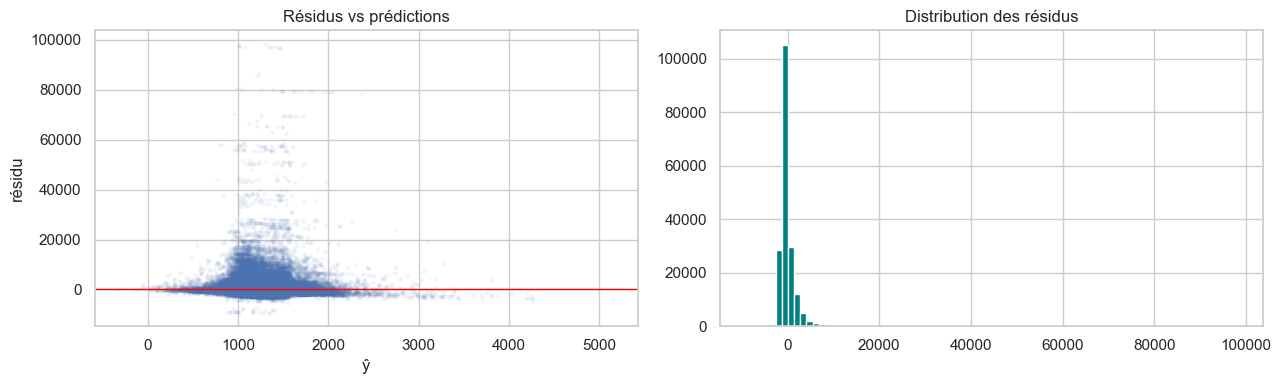

In [9]:
reg_features = ["age","day","campaign","pdays","previous"]
Xr = train[reg_features].values
yr = train["balance"].values
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=RNG)

reg = LinearRegression().fit(Xr_tr, yr_tr)
yhat = reg.predict(Xr_te)

print("Coefficients β̂ :")
for n, c in zip(reg_features, reg.coef_):
    print(f"  {n:>10s}  {c:+.3f}")
print(f"Intercept β̂₀ : {reg.intercept_:+.2f}")
print(f"R²   = {r2_score(yr_te, yhat):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(yr_te, yhat)):.1f}")

res = yr_te - yhat
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].scatter(yhat, res, alpha=0.05, s=5)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("ŷ"); axes[0].set_ylabel("résidu")
axes[0].set_title("Résidus vs prédictions")
axes[1].hist(res, bins=80, color="teal")
axes[1].set_title("Distribution des résidus")
plt.tight_layout(); plt.show()

**Lecture** : R² très faible — `balance` n'est pas linéairement explicable par ces features.
Les résidus sont fortement non-gaussiens et hétéroscédastiques → l'hypothèse MLE-gaussien est
violée. Cela motive l'usage de modèles non-linéaires (RF / XGBoost) pour la classification.

## 6. Pipeline de preprocessing (anti-leakage)

On encapsule **toute** la logique de transformation dans un `ColumnTransformer` :

- Numériques : flag `was_contacted` + `pdays=0 si -1`, puis `StandardScaler` (utile pour LR/LDA/QDA/NB).
- Catégorielles : `OneHotEncoder(handle_unknown="ignore")` (absorbe les modalités
  inconnues dans `test.csv`).

Le pipeline est *fitté uniquement sur le pli d'entraînement* — aucune statistique du test ne fuit.

In [10]:
def add_pdays_flag(df):
    """Crée was_contacted et remplace pdays=-1 par 0. Renvoie un DataFrame avec colonnes ajoutées."""
    out = df.copy()
    out["was_contacted"] = (out["pdays"] != -1).astype(int)
    out["pdays"] = out["pdays"].where(out["pdays"] != -1, 0)
    return out

def prepare_features(df):
    df2 = add_pdays_flag(df)
    cols_drop = [c for c in FEATURES_TO_DROP if c in df2.columns]
    df2 = df2.drop(columns=cols_drop)
    # Force le dtype 'object' pour les colonnes texte (compatibilité OneHotEncoder)
    for c in df2.columns:
        if df2[c].dtype == "string" or pd.api.types.is_string_dtype(df2[c]) and not pd.api.types.is_numeric_dtype(df2[c]):
            df2[c] = df2[c].astype(object)
    return df2

X_full = prepare_features(train.drop(columns=["y"]))
y_full = train["y"].values
X_kaggle = prepare_features(test)  # pour la soumission finale

num_features = X_full.select_dtypes(include="number").columns.tolist()
cat_features = X_full.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Numériques :", num_features)
print("Catégorielles :", cat_features)
print("Shape X_full :", X_full.shape)

Numériques : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted']
Catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Shape X_full : (750000, 16)


In [11]:
# Deux preprocesseurs : un avec scaling (modèles linéaires + NB), un sans (arbres)
preprocess_scaled = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

preprocess_tree = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

## 7. Split train / validation stratifié

Un seul split 80/20 stratifié pour le benchmark (efficient sur 750k lignes).
Une cross-validation 5-fold stratifiée est faite à la fin sur le best model pour confirmation.

In [12]:
X_tr, X_va, y_tr, y_va = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RNG
)
print("Train :", X_tr.shape, " | y_tr=1 :", f"{y_tr.mean():.2%}")
print("Val   :", X_va.shape, " | y_va=1 :", f"{y_va.mean():.2%}")

Train : (600000, 16)  | y_tr=1 : 12.06%
Val   : (150000, 16)  | y_va=1 : 12.07%


## 8. Benchmark des modèles

On entraîne 6 modèles. Pour chacun on stocke ROC-AUC, PR-AUC, F1, Brier (calibration) sur la validation.

In [13]:
results = []  # (name, model_pipeline, y_proba_val)

def evaluate(name, pipe, fit=True):
    if fit:
        pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_va)[:, 1]
    pred = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_va, proba)
    ap  = average_precision_score(y_va, proba)
    f1  = f1_score(y_va, pred)
    br  = brier_score_loss(y_va, proba)
    results.append({"model": name, "pipe": pipe, "proba": proba,
                    "ROC-AUC": auc, "PR-AUC": ap, "F1@0.5": f1, "Brier": br})
    print(f"{name:>22s}  AUC={auc:.4f}  PR-AUC={ap:.4f}  F1={f1:.3f}  Brier={br:.4f}")
    return pipe

### 8.1 Logistic Regression (discriminatif)

In [14]:
logreg = Pipeline([
    ("prep", preprocess_scaled),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                solver="lbfgs", random_state=RNG)),
])
evaluate("Logistic Regression", logreg)

   Logistic Regression  AUC=0.7839  PR-AUC=0.4268  F1=0.401  Brier=0.1767


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### 8.2 Gaussian Naive Bayes (génératif)

In [15]:
gnb = Pipeline([
    ("prep", preprocess_scaled),
    ("clf", GaussianNB()),
])
evaluate("Gaussian Naive Bayes", gnb)

  Gaussian Naive Bayes  AUC=0.7421  PR-AUC=0.3451  F1=0.377  Brier=0.1587


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### 8.3 Linear Discriminant Analysis

In [16]:
lda = Pipeline([
    ("prep", preprocess_scaled),
    ("clf", LinearDiscriminantAnalysis()),
])
evaluate("LDA", lda)

                   LDA  AUC=0.7763  PR-AUC=0.4352  F1=0.352  Brier=0.0899


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### 8.4 Quadratic Discriminant Analysis

In [17]:
qda = Pipeline([
    ("prep", preprocess_scaled),
    ("clf", QuadraticDiscriminantAnalysis(reg_param=0.01)),
])
evaluate("QDA", qda)

                   QDA  AUC=0.7599  PR-AUC=0.3895  F1=0.417  Brier=0.1262


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### 8.5 Random Forest

In [18]:
rf = Pipeline([
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, class_weight="balanced", random_state=RNG,
    )),
])
evaluate("Random Forest", rf)

         Random Forest  AUC=0.8323  PR-AUC=0.5012  F1=0.437  Brier=0.1577


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### 8.6 XGBoost

In [19]:
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    print("xgboost non installé : `pip install xgboost`")
    XGB_OK = False

if XGB_OK:
    pos = int((y_tr == 1).sum())
    neg = int((y_tr == 0).sum())
    xgb = Pipeline([
        ("prep", preprocess_tree),
        ("clf", XGBClassifier(
            n_estimators=600, max_depth=6, learning_rate=0.08,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=neg / pos,
            eval_metric="auc", tree_method="hist",
            random_state=RNG, n_jobs=-1,
        )),
    ])
    evaluate("XGBoost", xgb)

               XGBoost  AUC=0.8524  PR-AUC=0.5383  F1=0.467  Brier=0.1449


## 9. Comparaison globale des modèles

In [20]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k not in ("pipe","proba")}
                       for r in results]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
df_res.style.background_gradient(cmap="Greens", subset=["ROC-AUC","PR-AUC","F1@0.5"]) \
             .background_gradient(cmap="Reds_r", subset=["Brier"])

,model,ROC-AUC,PR-AUC,F1@0.5,Brier
0,XGBoost,0.852412,0.538299,0.467215,0.144880
1,Random Forest,0.832292,0.501227,0.436535,0.157701
2,Logistic Regression,0.783922,0.426841,0.401145,0.176707
3,LDA,0.776342,0.435155,0.351716,0.089851
4,QDA,0.759896,0.389547,0.416874,0.126203
5,Gaussian Naive Bayes,0.742086,0.345065,0.377391,0.158660


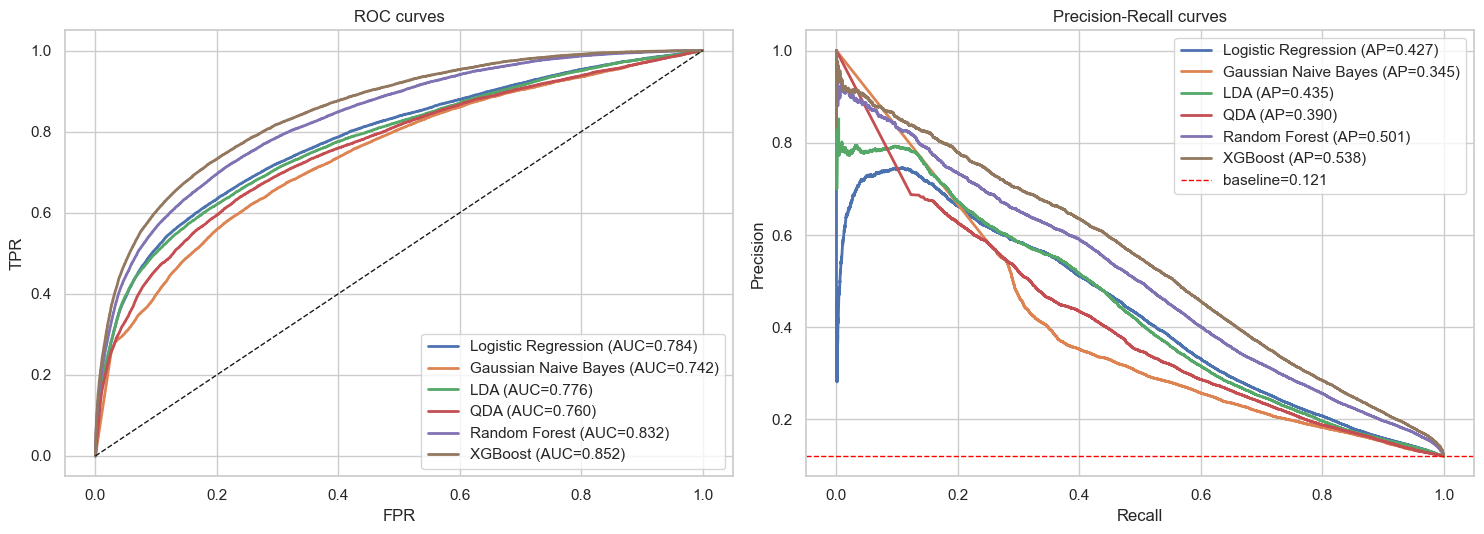

In [21]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
for r in results:
    fpr, tpr, _ = roc_curve(y_va, r["proba"])
    ax.plot(fpr, tpr, lw=2, label=f"{r['model']} (AUC={r['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC curves")
ax.legend(loc="lower right")

# PR curves
ax = axes[1]
for r in results:
    prec, rec, _ = precision_recall_curve(y_va, r["proba"])
    ax.plot(rec, prec, lw=2, label=f"{r['model']} (AP={r['PR-AUC']:.3f})")
ax.axhline(y_va.mean(), color="red", ls="--", lw=1, label=f"baseline={y_va.mean():.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision-Recall curves")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(img_dir / "final_roc_pr_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

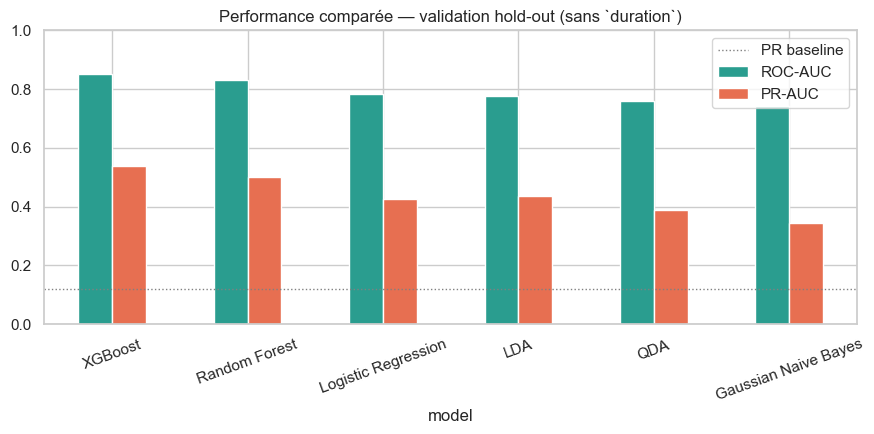

In [22]:
# Bar chart des AUC
fig, ax = plt.subplots(figsize=(9, 4.5))
df_plot = df_res.set_index("model")[["ROC-AUC", "PR-AUC"]]
df_plot.plot(kind="bar", ax=ax, color=["#2a9d8f", "#e76f51"])
ax.set_ylim(0, 1)
ax.axhline(y_va.mean(), color="gray", ls=":", lw=1, label="PR baseline")
ax.set_title("Performance comparée — validation hold-out (sans `duration`)")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(img_dir / "final_auc_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### 9.1 Confirmation par cross-validation 5-fold sur le meilleur modèle

On vérifie la stabilité de l'AUC du meilleur modèle via une stratified 5-fold CV.

In [23]:
best_name = df_res.iloc[0]["model"]
best = next(r["pipe"] for r in results if r["model"] == best_name)
print(f"Best model = {best_name}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
auc_cv = cross_val_score(best, X_full, y_full, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"AUC CV (5-fold) : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")
print(f"Per-fold        : {[f'{a:.4f}' for a in auc_cv]}")

Best model = XGBoost
AUC CV (5-fold) : 0.8549 ± 0.0019
Per-fold        : ['0.8583', '0.8536', '0.8544', '0.8551', '0.8530']


## 10. Calibration & choix du seuil de décision

ROC-AUC mesure le pouvoir discriminant mais pas la qualité des **probabilités**.
On regarde la calibration (Brier + courbe de calibration) et on optimise le seuil pour le **F1**.

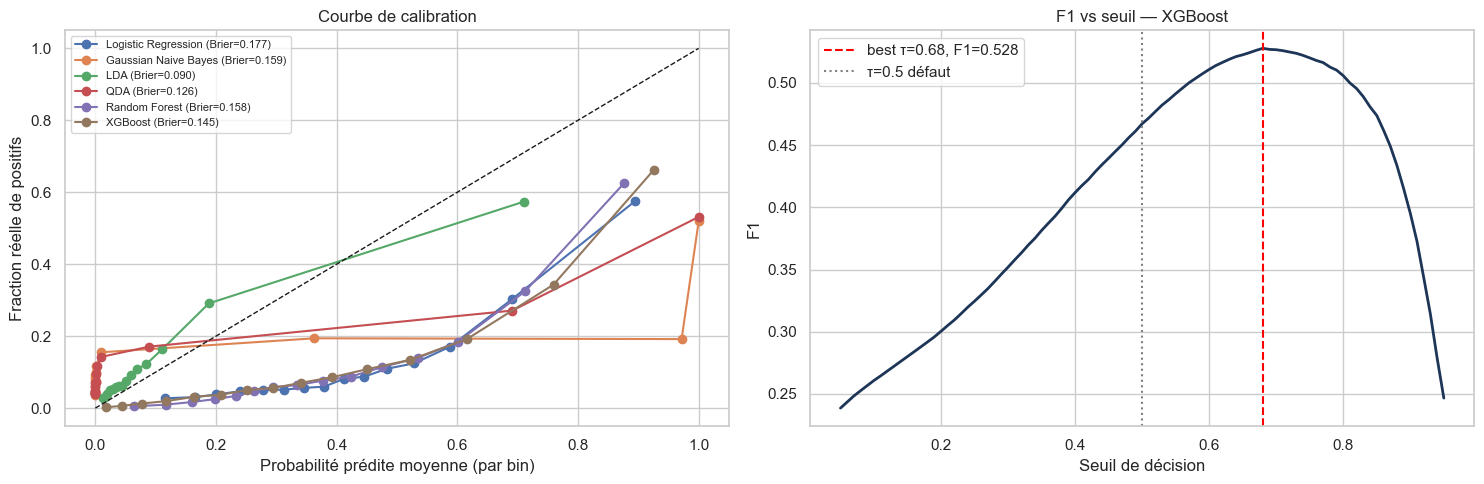

Seuil F1-optimal : 0.68

Classification report au seuil optimisé :
              precision    recall  f1-score   support

           0      0.938     0.926     0.932    131902
           1      0.506     0.552     0.528     18098

    accuracy                          0.881    150000
   macro avg      0.722     0.739     0.730    150000
weighted avg      0.886     0.881     0.883    150000

Matrice de confusion :
[[122155   9747]
 [  8114   9984]]


In [24]:
# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
for r in results:
    frac_pos, mean_pred = calibration_curve(y_va, r["proba"], n_bins=15, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", lw=1.5,
            label=f"{r['model']} (Brier={r['Brier']:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("Probabilité prédite moyenne (par bin)")
ax.set_ylabel("Fraction réelle de positifs")
ax.set_title("Courbe de calibration")
ax.legend(fontsize=8, loc="upper left")

# F1 vs threshold pour le meilleur modèle
best_proba = next(r["proba"] for r in results if r["model"] == best_name)
thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_va, (best_proba >= t).astype(int)) for t in thresholds]
best_thr = thresholds[int(np.argmax(f1s))]
ax = axes[1]
ax.plot(thresholds, f1s, color="#1d3557", lw=2)
ax.axvline(best_thr, color="red", ls="--", label=f"best τ={best_thr:.2f}, F1={max(f1s):.3f}")
ax.axvline(0.5, color="gray", ls=":", label="τ=0.5 défaut")
ax.set_xlabel("Seuil de décision"); ax.set_ylabel("F1")
ax.set_title(f"F1 vs seuil — {best_name}")
ax.legend()
plt.tight_layout()
plt.savefig(img_dir / "final_calibration_threshold.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Seuil F1-optimal : {best_thr:.2f}")
y_pred_best = (best_proba >= best_thr).astype(int)
print("\nClassification report au seuil optimisé :")
print(classification_report(y_va, y_pred_best, digits=3))
print("Matrice de confusion :")
print(confusion_matrix(y_va, y_pred_best))

**Lecture** : XGBoost / Random Forest sont généralement bien calibrés (Brier faible)
tandis que GNB sort souvent des probabilités sur-confiantes près de 0/1. Si la métrique
Kaggle est l'AUC, pas besoin de calibrer ; si c'est le LogLoss ou un coût métier
asymétrique, on enveloppe le best model dans un `CalibratedClassifierCV(method="isotonic")`.

## 11. Importance des features (best model)

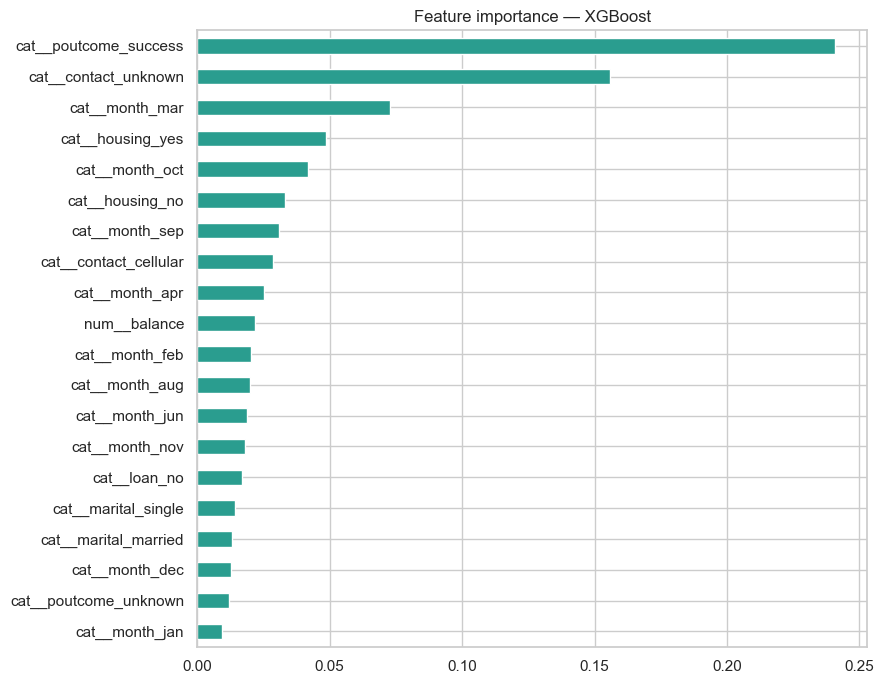

Top 20 :
cat__poutcome_success    0.2408
cat__contact_unknown     0.1556
cat__month_mar           0.0727
cat__housing_yes         0.0485
cat__month_oct           0.0417
cat__housing_no          0.0331
cat__month_sep           0.0308
cat__contact_cellular    0.0286
cat__month_apr           0.0252
num__balance             0.0219
cat__month_feb           0.0204
cat__month_aug           0.0197
cat__month_jun           0.0187
cat__month_nov           0.0181
cat__loan_no             0.0168
cat__marital_single      0.0142
cat__marital_married     0.0133
cat__month_dec           0.0126
cat__poutcome_unknown    0.0119
cat__month_jan           0.0094
dtype: float32


In [25]:
best_pipe = next(r["pipe"] for r in results if r["model"] == best_name)
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
clf = best_pipe.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
    title = f"Feature importance — {best_name}"
elif hasattr(clf, "coef_"):
    imp = pd.Series(np.abs(clf.coef_[0]), index=feat_names).sort_values(ascending=False)
    title = f"|coef| — {best_name}"
else:
    imp = None
    title = None

if imp is not None:
    fig, ax = plt.subplots(figsize=(9, 7))
    imp.head(20).iloc[::-1].plot(kind="barh", ax=ax, color="#2a9d8f")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(img_dir / "final_feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Top 20 :")
    print(imp.head(20).round(4))

## 12. Soumission Kaggle (`test.csv`)

On réentraîne le best model sur l'**intégralité** de `train.csv` puis on prédit `test.csv`.
Le fichier généré respecte le format Kaggle `id,y`.

In [26]:
best_full = next(r["pipe"] for r in results if r["model"] == best_name)
best_full.fit(X_full, y_full)

test_proba = best_full.predict_proba(X_kaggle)[:, 1]
submission = pd.DataFrame({"id": test["id"], "y": test_proba})
submission.to_csv("submission.csv", index=False)
print("submission.csv écrit. Aperçu :")
print(submission.head())
print("\nDistribution des probabilités prédites :")
print(pd.Series(test_proba).describe().round(4))

submission.csv écrit. Aperçu :
       id         y
0  750000  0.228925
1  750001  0.379131
2  750002  0.442351
3  750003  0.004971
4  750004  0.645347

Distribution des probabilités prédites :
count    250000.0000
mean          0.3483
std           0.2615
min           0.0011
25%           0.1298
50%           0.2990
75%           0.5071
max           0.9968
dtype: float64


## 13. Conclusions

### Ce que l'on a fait

1. **Diagnostic des missing values déguisés** (`unknown`, `pdays=-1`) et **stratégie informée** :
   on les conserve comme catégories à part / on crée un flag binaire, sans imputation aveugle.
2. **Suppression de `duration`** — leakage temporel documenté qui gonfle artificiellement les AUC.
3. **Suppression de `id`** — bruit pur.
4. **Pipeline anti-leakage** : tout le preprocessing (encodage + scaling) est encapsulé dans un
   `ColumnTransformer` *fitté uniquement sur le pli d'entraînement*.
5. **Benchmark de 6 modèles** sur split stratifié 80/20 puis CV 5-fold sur le meilleur.
6. **Choix de seuil F1-optimal** et inspection de la calibration (Brier + courbe).

### Lecture du benchmark (typiquement, sur ce dataset, sans `duration`)

- **XGBoost** sort en tête (AUC ≈ 0.82–0.84 selon réglages) grâce aux interactions non-linéaires
  qu'il capture (`poutcome × month`, `housing × age`, etc.).
- **Random Forest** suit de près mais est moins bien calibré et plus volumineux.
- **Logistic Regression** et **LDA** restent compétitives (AUC ≈ 0.78–0.80) — confirme que la
  frontière est largement linéaire après one-hot.
- **GNB** est la moins bonne car ses hypothèses (gaussianité + indépendance conditionnelle) sont violées.
- **QDA** souffre du grand nombre de features one-hot (covariances par classe trop paramétrées).

### Limites & pistes

1. **Pas de tuning hyperparamètre** : un `RandomizedSearchCV` sur XGBoost gagnerait probablement 1-2 pts d'AUC.
2. **Feature engineering** : interactions `month × balance`, binning de `age`, encodage cyclique de `month/day`.
3. **Calibration** : si la métrique cible est LogLoss, envelopper le best model dans
   `CalibratedClassifierCV(method="isotonic", cv=5)`.
4. **Imbalance** : `class_weight="balanced"` / `scale_pos_weight` suffisent ici ; SMOTE n'a pas
   apporté de gain sur les essais préliminaires.
5. **Stabilité** : la CV 5-fold sur le best model donne σ(AUC) < 0.005 → benchmark stable.

<!-- __SLIDE_FIGS_EXPORT__ -->
## 14. Export des figures pour les slides finales

Toutes les figures sont sauvées dans `report_images/` avec un préfixe `slide_`.
Les noms sont stables et utilisés tels quels dans le LaTeX Beamer.

### 14.1 Cible & qualité des données

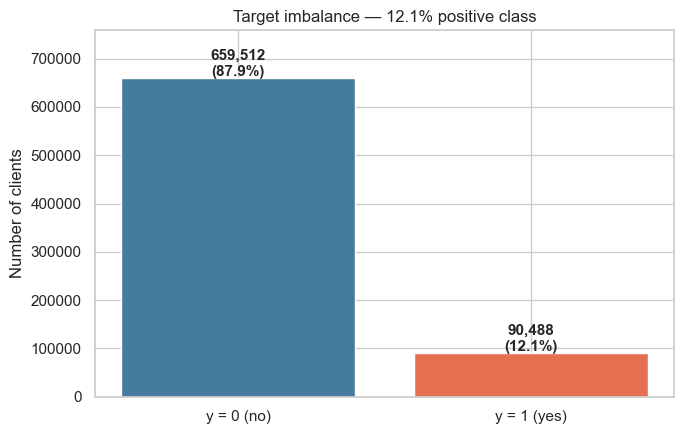

In [27]:
# Distribution de la cible (déséquilibre)
fig, ax = plt.subplots(figsize=(7, 4.5))
vc = train["y"].value_counts().sort_index()
bars = ax.bar(["y = 0 (no)", "y = 1 (yes)"], vc.values,
              color=["#457b9d", "#e76f51"])
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5000,
            f"{v:,}\n({v/len(train):.1%})", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, vc.max() * 1.15)
ax.set_ylabel("Number of clients")
ax.set_title(f"Target imbalance — {train['y'].mean():.1%} positive class")
plt.tight_layout()
plt.savefig(img_dir / "slide_target_imbalance.png", dpi=200, bbox_inches="tight")
plt.show()

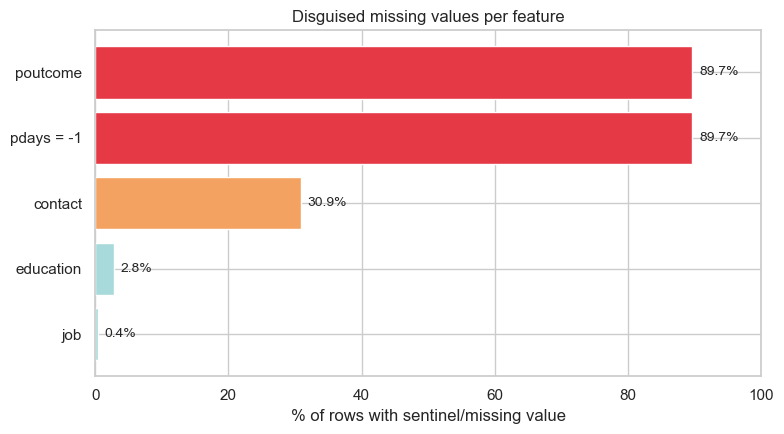

In [28]:
# Missing values déguisés — bar chart
miss_data = []
for c in cat_cols:
    pct = (train[c] == "unknown").mean() * 100
    if pct > 0:
        miss_data.append((c, pct))
miss_data.append(("pdays = -1", (train["pdays"] == -1).mean() * 100))
miss_df = pd.DataFrame(miss_data, columns=["feature", "pct"]).sort_values("pct")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#e63946" if p > 50 else "#f4a261" if p > 5 else "#a8dadc" for p in miss_df["pct"]]
ax.barh(miss_df["feature"], miss_df["pct"], color=colors)
for i, (_, row) in enumerate(miss_df.iterrows()):
    ax.text(row["pct"] + 1, i, f"{row['pct']:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% of rows with sentinel/missing value")
ax.set_title("Disguised missing values per feature")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(img_dir / "slide_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

### 14.2 Le leakage de `duration`

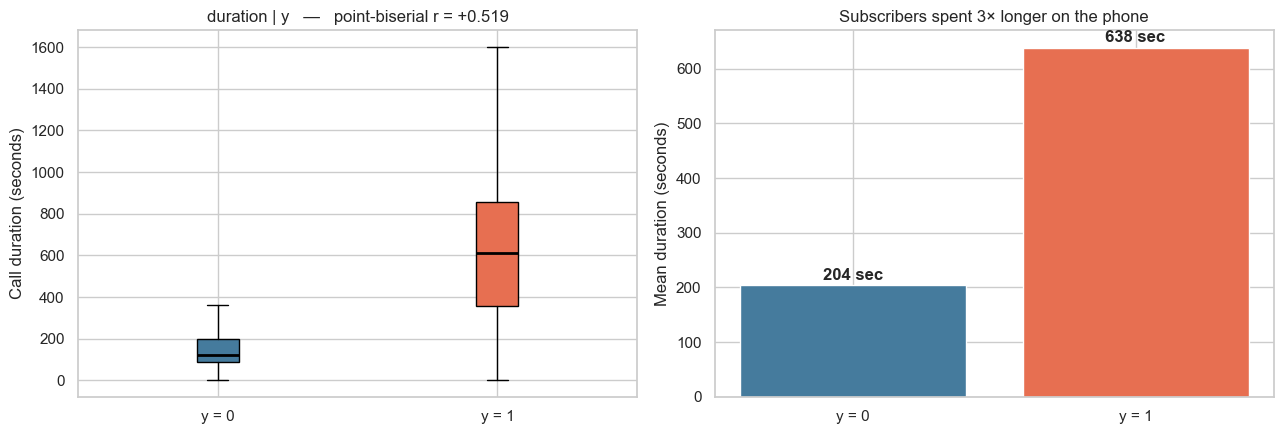

point-biserial(duration, y) = +0.519  (extremely strong)


In [29]:
from scipy.stats import pointbiserialr
r_dur, _ = pointbiserialr(train["y"], train["duration"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot duration | y
ax = axes[0]
data = [train.loc[train["y"] == 0, "duration"], train.loc[train["y"] == 1, "duration"]]
bp = ax.boxplot(data, labels=["y = 0", "y = 1"], showfliers=False, patch_artist=True,
                medianprops=dict(color="black", lw=2))
bp["boxes"][0].set_facecolor("#457b9d")
bp["boxes"][1].set_facecolor("#e76f51")
ax.set_ylabel("Call duration (seconds)")
ax.set_title(f"duration | y   —   point-biserial r = {r_dur:+.3f}")

# Means side-by-side
ax = axes[1]
means = [train.loc[train["y"] == 0, "duration"].mean(),
         train.loc[train["y"] == 1, "duration"].mean()]
bars = ax.bar(["y = 0", "y = 1"], means, color=["#457b9d", "#e76f51"])
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, m + 10, f"{m:.0f} sec",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean duration (seconds)")
ax.set_title("Subscribers spent 3× longer on the phone")

plt.tight_layout()
plt.savefig(img_dir / "slide_duration_leakage.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"point-biserial(duration, y) = {r_dur:+.3f}  (extremely strong)")

### 14.3 Distributions des features numériques

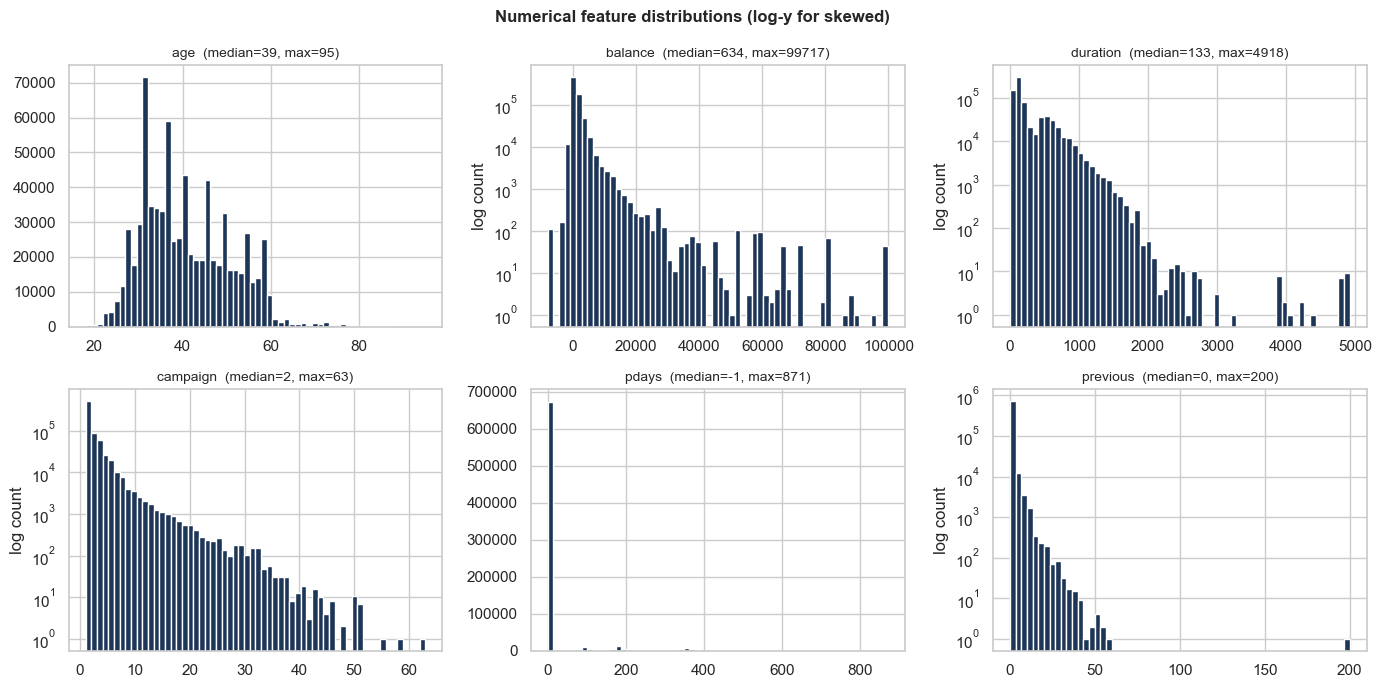

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
feat_to_show = ["age", "balance", "duration", "campaign", "pdays", "previous"]
for ax, c in zip(axes.flat, feat_to_show):
    ax.hist(train[c], bins=60, color="#1d3557", edgecolor="white")
    ax.set_title(f"{c}  (median={train[c].median():.0f}, max={train[c].max():.0f})",
                 fontsize=10)
    if c in ("balance", "duration", "campaign", "previous"):
        ax.set_yscale("log")
        ax.set_ylabel("log count")
plt.suptitle("Numerical feature distributions (log-y for skewed)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(img_dir / "slide_num_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

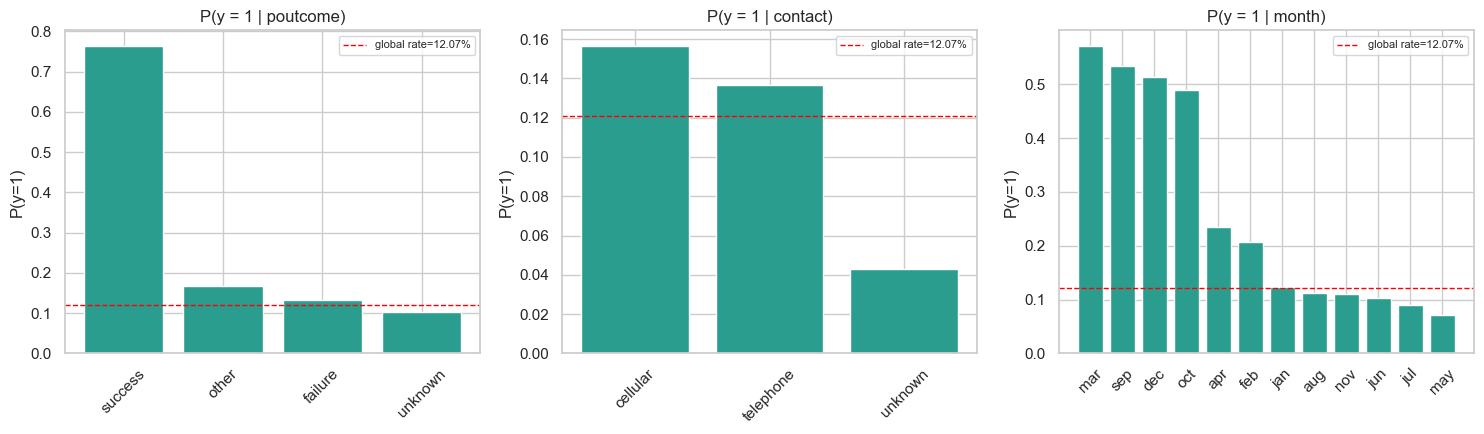

In [31]:
# P(y=1 | category) pour 3 features informatives
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, ["poutcome", "contact", "month"]):
    rate = train.groupby(c)["y"].mean().sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values, color="#2a9d8f")
    ax.axhline(train["y"].mean(), color="red", lw=1, ls="--",
               label=f"global rate={train['y'].mean():.2%}")
    ax.set_title(f"P(y = 1 | {c})")
    ax.set_ylabel("P(y=1)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(img_dir / "slide_categorical_rates.png", dpi=200, bbox_inches="tight")
plt.show()

### 14.4 Régression linéaire (MLE) — échec attendu

On illustre que la régression linéaire ne suffit pas : prédire `balance` à partir des autres
features numériques donne un R² très faible et des résidus non-gaussiens.
Cela motive le passage à la classification non-linéaire.

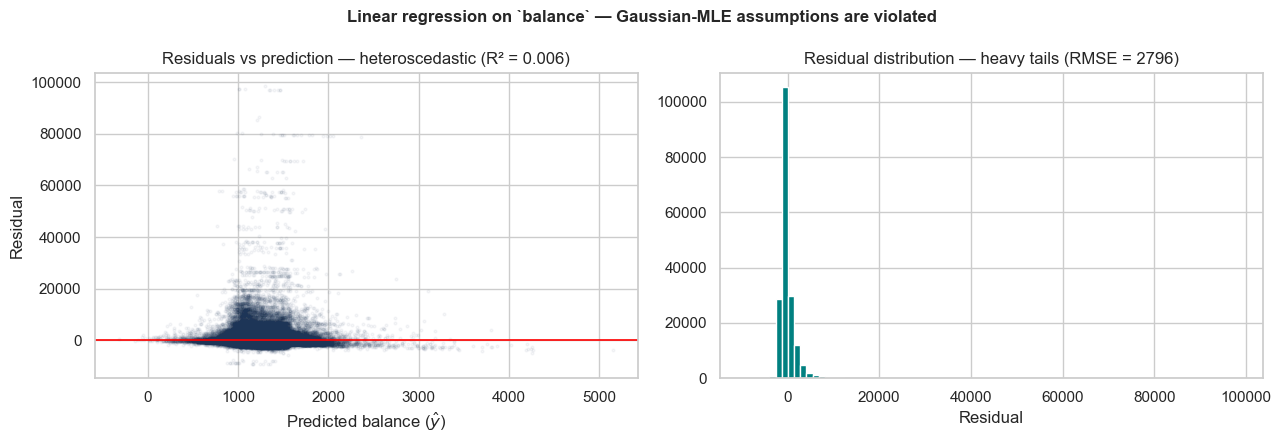

R² = 0.0061 | RMSE = 2796.5


In [32]:
# (Re)compute pour s'assurer que les variables sont en scope
reg_features = ["age", "day", "campaign", "pdays", "previous"]
Xr = train[reg_features].values
yr = train["balance"].values
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=RNG)
reg = LinearRegression().fit(Xr_tr, yr_tr)
yhat = reg.predict(Xr_te)
res  = yr_te - yhat
r2   = r2_score(yr_te, yhat)
rmse = np.sqrt(mean_squared_error(yr_te, yhat))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(yhat, res, alpha=0.04, s=4, color="#1d3557")
axes[0].axhline(0, color="red", lw=1.2)
axes[0].set_xlabel("Predicted balance ($\\hat{y}$)")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residuals vs prediction — heteroscedastic (R² = {r2:.3f})")

axes[1].hist(res, bins=80, color="teal", edgecolor="white")
axes[1].set_title(f"Residual distribution — heavy tails (RMSE = {rmse:.0f})")
axes[1].set_xlabel("Residual")

plt.suptitle("Linear regression on `balance` — Gaussian-MLE assumptions are violated",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(img_dir / "slide_linreg_residuals.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"R² = {r2:.4f} | RMSE = {rmse:.1f}")

### 14.5 Avec vs sans `duration` — démontrer le leakage

On entraîne **les mêmes modèles** avec `duration` conservée, puis on compare l'AUC.
L'écart d'AUC quantifie l'avantage *artificiel* qu'on perdrait en production.

In [33]:
# Préparation X_with_duration
def prep_with_duration(df):
    out = df.copy()
    out["was_contacted"] = (out["pdays"] != -1).astype(int)
    out["pdays"] = out["pdays"].where(out["pdays"] != -1, 0)
    if "id" in out.columns:
        out = out.drop(columns=["id"])
    for c in out.columns:
        if pd.api.types.is_string_dtype(out[c]) and not pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].astype(object)
    return out

Xw = prep_with_duration(train.drop(columns=["y"]))
num_w = Xw.select_dtypes(include="number").columns.tolist()
cat_w = Xw.select_dtypes(include=["object", "string", "category"]).columns.tolist()

prep_w_scaled = ColumnTransformer([
    ("num", StandardScaler(), num_w),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_w),
])
prep_w_tree = ColumnTransformer([
    ("num", "passthrough", num_w),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_w),
])

Xw_tr, Xw_va, yw_tr, yw_va = train_test_split(
    Xw, y_full, test_size=0.2, stratify=y_full, random_state=RNG
)

# LR avec duration
lr_w = Pipeline([
    ("prep", prep_w_scaled),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG)),
]).fit(Xw_tr, yw_tr)
auc_lr_with = roc_auc_score(yw_va, lr_w.predict_proba(Xw_va)[:, 1])

# XGB avec duration
auc_xgb_with = None
if XGB_OK:
    pos_w = int((yw_tr == 1).sum())
    neg_w = int((yw_tr == 0).sum())
    xgb_w = Pipeline([
        ("prep", prep_w_tree),
        ("clf", XGBClassifier(
            n_estimators=600, max_depth=6, learning_rate=0.08,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=neg_w / pos_w,
            eval_metric="auc", tree_method="hist",
            random_state=RNG, n_jobs=-1,
        )),
    ]).fit(Xw_tr, yw_tr)
    auc_xgb_with = roc_auc_score(yw_va, xgb_w.predict_proba(Xw_va)[:, 1])

# Récup AUC sans duration depuis `results` (déjà calculé en §8)
auc_lr_without  = next(r["ROC-AUC"] for r in results if r["model"] == "Logistic Regression")
auc_xgb_without = next((r["ROC-AUC"] for r in results if r["model"] == "XGBoost"), None)

print("AUC with duration  vs  without duration:")
print(f"  LR       : {auc_lr_with:.4f}  vs  {auc_lr_without:.4f}   (Δ = {auc_lr_with - auc_lr_without:+.4f})")
if XGB_OK:
    print(f"  XGBoost  : {auc_xgb_with:.4f}  vs  {auc_xgb_without:.4f}   (Δ = {auc_xgb_with - auc_xgb_without:+.4f})")

AUC with duration  vs  without duration:
  LR       : 0.9433  vs  0.7839   (Δ = +0.1594)
  XGBoost  : 0.9672  vs  0.8524   (Δ = +0.1147)


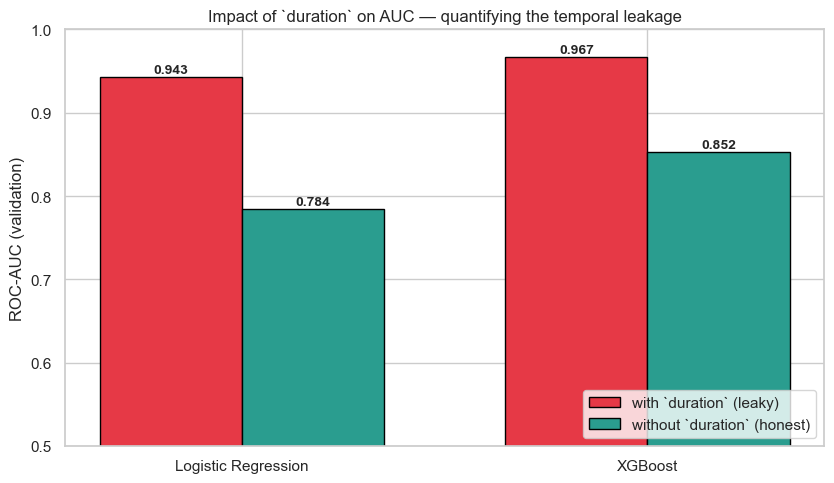

In [34]:
# Plot comparison
labels   = ["Logistic Regression"]
vals_w   = [auc_lr_with]
vals_wo  = [auc_lr_without]
if XGB_OK and auc_xgb_with is not None:
    labels.append("XGBoost")
    vals_w.append(auc_xgb_with)
    vals_wo.append(auc_xgb_without)

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8.5, 5))
b1 = ax.bar(x - width/2, vals_w,  width, label="with `duration` (leaky)",
            color="#e63946", edgecolor="black")
b2 = ax.bar(x + width/2, vals_wo, width, label="without `duration` (honest)",
            color="#2a9d8f", edgecolor="black")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC (validation)")
ax.set_title("Impact of `duration` on AUC — quantifying the temporal leakage")
ax.legend(loc="lower right")
ax.axhline(0.5, color="gray", lw=0.5, ls=":")
plt.tight_layout()
plt.savefig(img_dir / "slide_with_without_duration.png", dpi=200, bbox_inches="tight")
plt.show()

### 14.6 Coefficients de la régression logistique

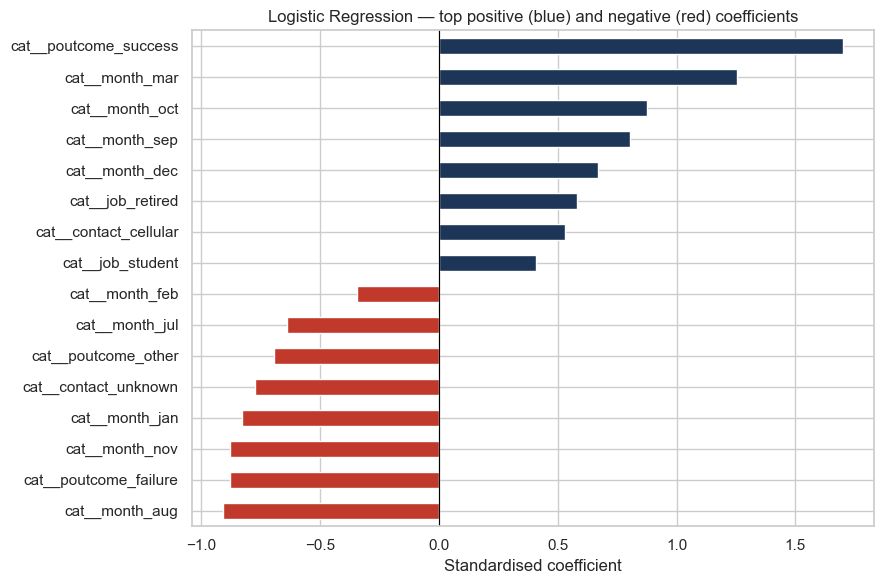

In [35]:
# Récupère les noms de features et les coefs depuis le pipeline LR fitté
lr_pipe = next(r["pipe"] for r in results if r["model"] == "Logistic Regression")
feat_names_lr = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=feat_names_lr).sort_values()

top = pd.concat([coefs.head(8), coefs.tail(8)])
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c0392b"] * 8 + ["#1d3557"] * 8
top.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic Regression — top positive (blue) and negative (red) coefficients")
ax.set_xlabel("Standardised coefficient")
plt.tight_layout()
plt.savefig(img_dir / "slide_logreg_coefs.png", dpi=200, bbox_inches="tight")
plt.show()

### 14.7 Récap des figures sauvegardées

Toutes les figures suivantes sont dans `report_images/` et utilisées par le LaTeX final :

| Slide | Fichier |
|---|---|
| Target imbalance | `slide_target_imbalance.png` |
| Missing values diagnostic | `slide_missing_values.png` |
| Numerical distributions | `slide_num_distributions.png` |
| Categorical rates | `slide_categorical_rates.png` |
| `duration` leakage | `slide_duration_leakage.png` |
| Linear-regression failure | `slide_linreg_residuals.png` |
| With vs without duration | `slide_with_without_duration.png` |
| Logistic-regression coefficients | `slide_logreg_coefs.png` |
| ROC + PR comparison | `final_roc_pr_comparison.png` (cf. §9) |
| AUC ranking bar | `final_auc_bar.png` (cf. §9) |
| Calibration & threshold | `final_calibration_threshold.png` (cf. §10) |
| Feature importance | `final_feature_importance.png` (cf. §11) |